# Projektin Nimi (TBD)

Tony Karlin, Onni Kivinen, Joni Heikkilä, Jarkko Kärki

In [348]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report

from sklearn.tree import plot_tree

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler

from scripts.plot_functions import plot_accidents_by_year, plot_seriousness_by_year, plot_map, plot_accidents_by_place, accidents_by_place

## 1.0 Business understanding

### 1.1 Johdanto

Projektin tarkoituksena on tutkia Helsingin alueen liikenneonnettomuuksia. Liikenneonnettomuudet ovat usein erittäin vältettävissä, vaikkakin monesti onnettomuudet johtuvat inhimillisistä syistä kuten väsymyksestä, ylinopeudesta tai rattijuopumuksesta. Onnettomuuksissa vaanii myös toinen puoli, mikä ei ole aina yksilöiden käsissä. Nämä tekijät ovat niin sanottuja **taustariskejä** eli ympäristöön liittyviä riskejä.

Tässä työssä analysoimme tietoaineistoa vuosien 2000-2024 onnettomuuksista Helsingin eri osa-alueilla. Aineistolla pyrimme  tunnistamaan, esiintyykö onnettomuuksissa alueellisia keskittymiä, jolloin Helsingin Kaupunki voisi esimerkiksi tutkia, millaisia taustariskejä niihin mahdollisesti liittyy esim. tien kunto, nopeusalueet, heikko jalankulkijoiden näkyvyys.

### 1.2 Tavoite

Tavoitteena on selvittää tietoaineiston avulla seuraavat seikat:
- Missä päin kaupunkia on eniten onnettomuuksia?
- Mitkä onnettomuustyypit ovat yleisimpiä?
- Missä tapahtuu vakavimmat onnettomuudet?
- Ovatko onnettomuudet lisääntyneet vai vähentyneet vuosien ajan?
- Voidaanko onnettomuuden vakavuutta ennustaa sijainnin ja muiden muuttujien perusteella?

Näiden kysymyksien perusteella voitaisiin päätellä täytyykö alueiden taustariskitekijöitä tutkia.

### 1.3 Tutkimuskysymys

**Voiko liikenneonnettomuuden vakavuuden ennustaa sijainnin, onnettomuustyypin ja alueen perusteella?**

## 2.0 Data understanding

Päätietoainestona projektissa toimii [Liikenneonnettomuudet Helsingissä](https://avoindata.suomi.fi/data/fi/dataset/liikenneonnettomuudet-helsingissa/resource/0e396048-66ea-4b85-a1e3-2b387f29c378).

Tietoainesto sisältää Helsingissä tapahtuneiden liikenneottemuuksien tapahtumapaikat, vakavuustasteet ja onnettomuuslajit vuodesta 2000 alkaen.
Aineistoon lisätään [Helsingin piirijako](https://hri.fi/data/fi/dataset/helsingin-piirijako) aineistosta _"Osa-alue"_ ominaisuus.

- Tietoaineistot liitetään myöhemmin toisiinsa kartoittamalla aineistojen koordinaatit oikeisiin _Osa-alueisiin_.


In [349]:
geodata_filepath = "datasets/piirialuejako-1995-2019.gpkg"
areas = gpd.read_file(geodata_filepath, layer="osa_alue_2019")
suur_piirit = gpd.read_file(geodata_filepath, layer="suur_2019")

accidents_filepath = "datasets/liikenneonnettomuudet.csv"
accidents = pd.read_csv(accidents_filepath, sep=";", decimal=",")

print("Datasetin rivien määrä:", len(accidents))
accidents.head()

Datasetin rivien määrä: 53800


,LAJI,pohj_etrs,ita_etrs,VAKAV_A,VV
0,JK,6675786.73,25501661.91,1,2022
1,JK,6674533.32,25502790.94,2,2022
2,JK,6679536.47,25506837.81,2,2022
3,JK,6675297.68,25498807.13,2,2022
4,JK,6674924.21,25495525.13,2,2022


### Muuttujat
| Muuttuja  | Selitys             | Lisätiedot|
| --------- | ------------------- |---------|
| LAJI      | onnettomuustyyppi   |jk = jalankulkijaonnettomuus, pp = polkupyöräonnettomuus, mp = mopo/moottoripyöräonnettomuus, ma = moottoriajoneuvo-onnettomuus|
| pohj_etrs | pohjoiskoordinaatti |Pohjoiskoordinaatti ETRS-GK25-järjestelmässä|
| ita_etrs  | itäkoordinaatti     |Itäkoordinaatti ETRS-GK25-järjestelmässä|
| VAKAV_A   | vakavuus            |1 = omaisuusvahinko,  2 = loukkaantumiseen johtanut, 3 = kuolemaan johtanut|
| VV        | vuosi               | Vuosi jolloin onnettomuus tapahtunut|

In [350]:
accidents.info()

<class 'pandas.DataFrame'>
RangeIndex: 53800 entries, 0 to 53799
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LAJI       53800 non-null  str  
 1   pohj_etrs  53797 non-null  str  
 2   ita_etrs   53797 non-null  str  
 3   VAKAV_A    53800 non-null  int64
 4   VV         53800 non-null  int64
dtypes: int64(2), str(3)
memory usage: 2.1 MB


### 2.1 Data visualisointi

Aineiston visualisoinnissa tarkastellaan kuinka paljon vuosittain sattuu onnettomuuksia onnettomuustyypin ja vakavuuksia vuosien mukaan. Aineisto kattaa neljä onnettomuustyyppiä: jalankulkijaonnettomuudet (JK), polkupyörä- (PP), mopo- ,moottoripyörä- (MP) ja moottoriajoneuvo-onnettomuudet (MA). Lisäksi tarkastellaan onnettomuuksien vakavuutta kolmessa luokassa: omaisuusvahinko (1), loukkaantuminen (2) ja kuolema (3).

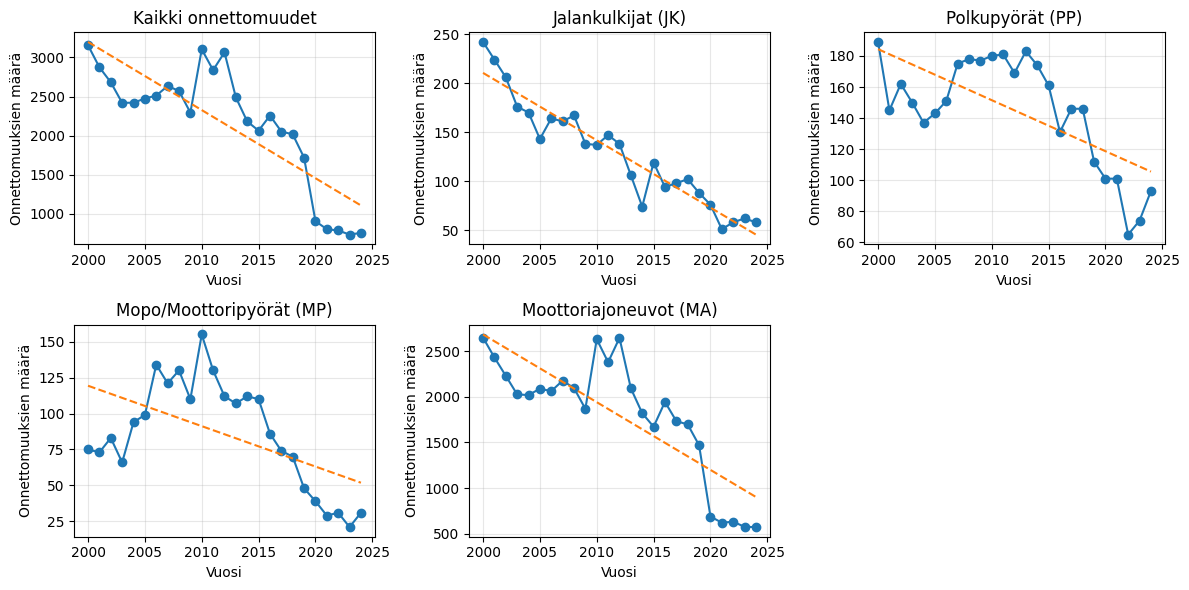

In [351]:
plot_accidents_by_year(accidents)

Onnettomuuksien kokonaismäärä on laskenut merkittävästi vuoden 2000 (3155) ja 2019 (1718) välillä.
Moottoriajoneuvo-onnettomuudet (MA) ovat selvästi yleisin tyyppi kattaen noin 80-85% kaikista tapauksista.
Polkupyöräonnettomuudet (PP) ovat pysyneet suhteellisen vakaina muihin tyyppeihin verrattuna, kun taas
mopo/moottoripyöräonnettomuudet (MP) kasvoivat 2005-2010 ja ovat sen jälkeen laskeneet voimakkaasti.

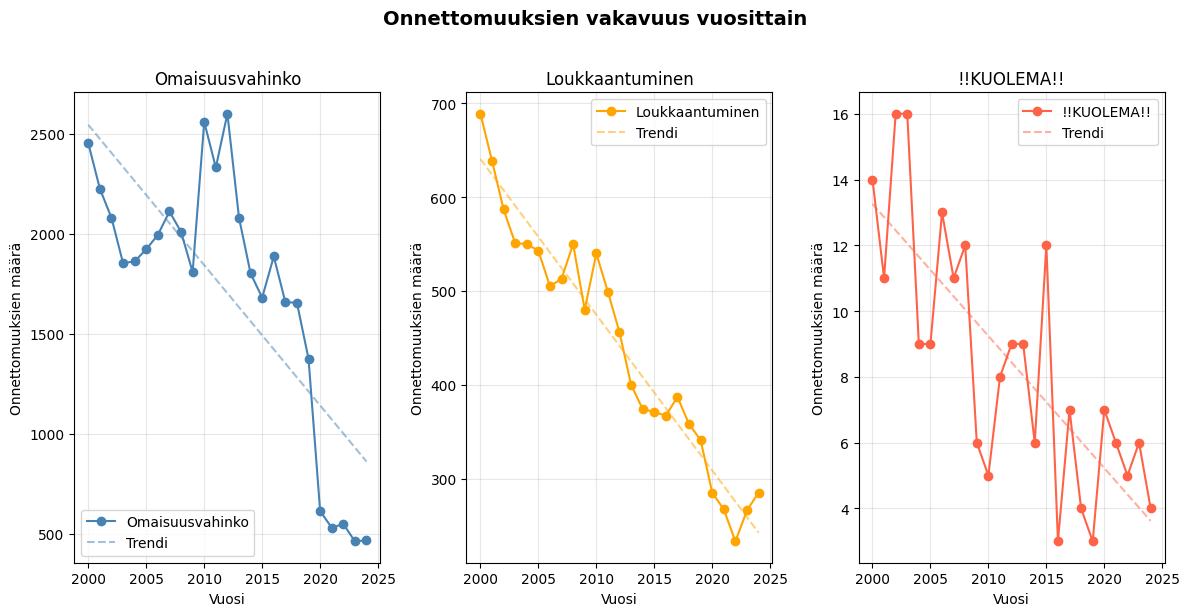

In [352]:
plot_seriousness_by_year(accidents)

Omaisuusvahinko-onnettomuudet ovat selvästi yleisin vakavuusluokka kattaen noin 75-80% kaikista tapauksista,
ja ne ovat laskeneet tasaisesti 2452:sta (2000) 1374:ään (2019).
Loukkaantumiseen johtaneet onnettomuudet ovat myös laskeneet 689:stä (2000) 341:een (2019).
Kuolemaan johtaneita onnettomuuksia on vuosittain erittäin vähän (3-16 tapausta),
ja niissä on myös havaittavissa laskeva trendi.

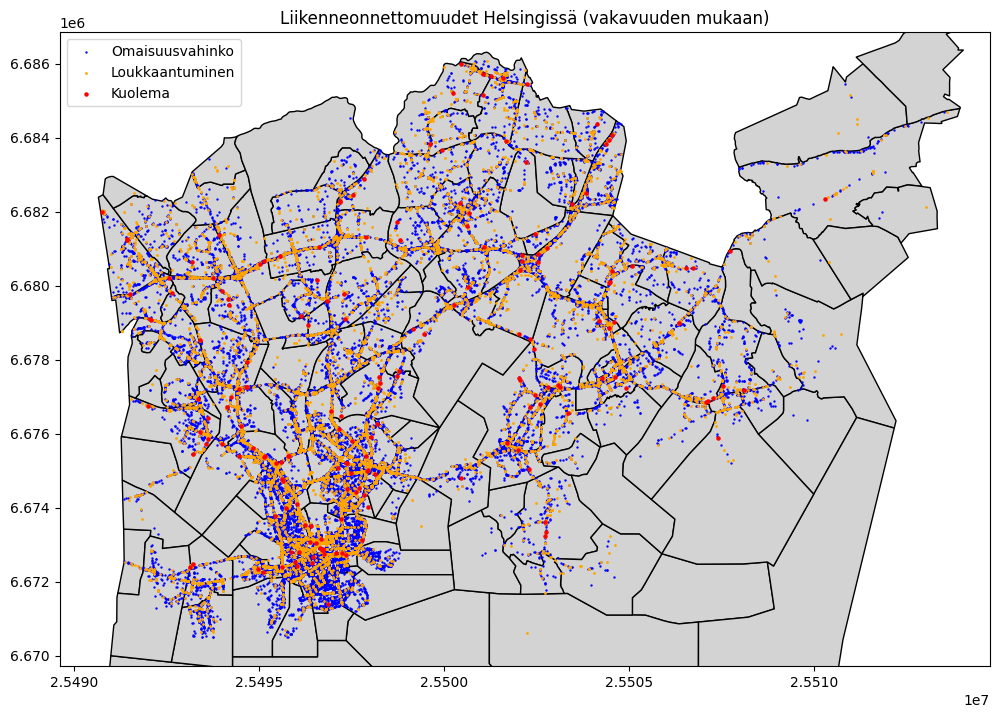

In [353]:
plot_map(accidents)

Kartasta voidaan havaita, että suurin osa onnettomuuksista keskittyy keskustan alueille. Lisäksi vakavimmat onnettomuudet erottuvat kartasta vilkkaiden väylien ja risteyksien läheisyydessä. 

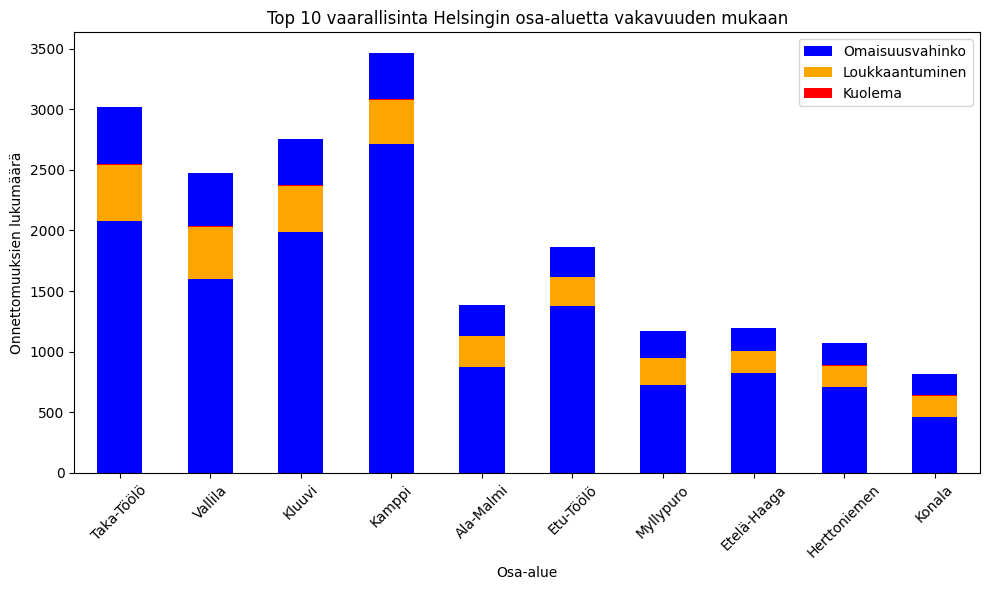

In [354]:
plot_accidents_by_place(accidents)

Pylväsdiagrammi todentaa havainnon, että suurin osa onnettomuuksista tapahtuu keskustan alueilla. Lisäksi kaaviosta huomataan, että omaisuusvahingot ovat yleisin onnettomuustyyppi, loukkaantumiset ovat harvinaisempia ja kuolemat kaikista harvinaisimpia.


## 3.0 Data preparation

Seuraavaksi yhdistetään piirialuejakotieto alkuperäiselle dataframelle erillisestä ``piirialuejako-1995-2019.gpkg`` tiedostosta. Tavoitteena lisätä siis kaupunginosa-sarake jokaiselle datariville, jotta voidaan nähdä suoraan mihin kaupunginosaan mikäkin datarivi sijoittuu.

In [ ]:
accidents = gpd.GeoDataFrame(
    accidents,
    geometry=gpd.points_from_xy(accidents["ita_etrs"], accidents["pohj_etrs"]),
    crs="EPSG:3879"
)
areas = areas.to_crs(accidents.crs)

accidents = gpd.sjoin(
    accidents,
    areas[["Nimi", "geometry"]],
    how="left",
    predicate="within"
)
accidents = accidents.rename(columns={"Nimi": "Osa-alue"})
accidents = accidents.drop(columns=["index_right"])

accidents = gpd.sjoin(
    accidents,
    suur_piirit[["Nimi", "geometry"]],
    how="left",
    predicate="within"
)
accidents = accidents.rename(columns={"Nimi": "Suur-piiri"})
accidents = accidents.drop(columns=["index_right", "geometry"])

Poistetaan puutteelliset rivit. Tämän jälkeen yhdistetään piirialuejako datasettiin.

In [356]:
rows_before = len(accidents)
accidents = accidents.dropna()
rows_after = len(accidents)

print(f"Pudotettiin {rows_before - rows_after} riviä.")

Pudotettiin 14 riviä.


In [357]:
accidents

,LAJI,pohj_etrs,ita_etrs,VAKAV_A,VV,Osa-alue,Suur-piiri
0,JK,6675786.73,25501661.91,1,2022,Länsi-Hertto,Kaakkoinen
1,JK,6674533.32,25502790.94,2,2022,Yliskylä,Kaakkoinen
2,JK,6679536.47,25506837.81,2,2022,Mellunmäki,Itäinen
3,JK,6675297.68,25498807.13,2,2022,Kalasatama,Keskinen
4,JK,6674924.21,25495525.13,2,2022,Taka-Töölö,Eteläinen
...,...,...,...,...,...,...,...
53795,PP,6674696.29,25497044.46,2,2024,Linjat,Keskinen
53796,PP,6675329.91,25497183.32,1,2024,Vallila,Keskinen
53797,PP,6675746.02,25494119.16,1,2024,Pikku Huopal,Läntinen
53798,PP,6678387.52,25494869.15,1,2024,Kivihaka,Läntinen


Uudelleennimetään ja uudelleenjärjestetään sarakkeet selkeyden vuoksi.

In [358]:
col_rename = {"LAJI": "O_Tyyppi", "pohj_etrs": "Pohj_coords", "ita_etrs": "Itä_coords","VAKAV_A": "Vakavuus", "VV": "Vuosi"}
accidents = accidents.rename(columns=col_rename)
accidents = accidents.iloc[:, [1, 2, 5, 6, 0, 4, 3]]
accidents.head()

,Pohj_coords,Itä_coords,Osa-alue,Suur-piiri,O_Tyyppi,Vuosi,Vakavuus
0,6675786.73,25501661.91,Länsi-Hertto,Kaakkoinen,JK,2022,1
1,6674533.32,25502790.94,Yliskylä,Kaakkoinen,JK,2022,2
2,6679536.47,25506837.81,Mellunmäki,Itäinen,JK,2022,2
3,6675297.68,25498807.13,Kalasatama,Keskinen,JK,2022,2
4,6674924.21,25495525.13,Taka-Töölö,Eteläinen,JK,2022,2


Nyt nähdään ETRS-GK25 (EPSG 3879) koordinaatiston kautta lisätyt kaupunginosatiedot on nyt yhdistetty taulukkoon.

Muutetaan data-arvot kategorisiksi/numeerisiksi arvoiksi, jotta niitä voidaan myöhemmin käyttää mallissa.

In [359]:
print(accidents.dtypes)

Pohj_coords      str
Itä_coords       str
Osa-alue         str
Suur-piiri       str
O_Tyyppi         str
Vuosi          int64
Vakavuus       int64
dtype: object


In [360]:
cols_to_categorical = ["Osa-alue", "O_Tyyppi"]
accidents[cols_to_categorical] = accidents[cols_to_categorical].astype("category")

cols_to_float = ["Pohj_coords", "Itä_coords"]
accidents[cols_to_float] = accidents[cols_to_float].astype(float)

Tarkistetaan setin datatyypit.

In [361]:
print(accidents.dtypes)

Pohj_coords     float64
Itä_coords      float64
Osa-alue       category
Suur-piiri          str
O_Tyyppi       category
Vuosi             int64
Vakavuus          int64
dtype: object


Viimeiseksi poistetaan vuodet 2019 jälkeen, koska avoindata.suomi.fi-sivuston mukaan data päivitettiin viimeksi 15. tammikuuta 2020, joten vuoden 2020 jälkeiset tiedot voivat olla puutteellisia tai virheellisiä.

In [362]:
accidents = accidents[accidents["Vuosi"] <= 2019]

In [363]:
accidents.describe(include='all')

,Pohj_coords,Itä_coords,Osa-alue,Suur-piiri,O_Tyyppi,Vuosi,Vakavuus
count,4.980900e+04,4.980900e+04,49809,49809,49809,49809.000000,49809.000000
unique,NaN,NaN,140,8,4,NaN,NaN
top,NaN,NaN,Kamppi,Eteläinen,MA,NaN,NaN
freq,NaN,NaN,3087,16615,41736,NaN,NaN
mean,6.676550e+06,2.549789e+07,NaN,NaN,NaN,2008.934349,1.202092
std,3.494289e+03,3.636223e+03,NaN,NaN,NaN,5.633722,0.410612
min,6.670495e+06,2.549076e+07,NaN,NaN,NaN,2000.000000,1.000000
25%,6.673280e+06,2.549564e+07,NaN,NaN,NaN,2004.000000,1.000000
50%,6.675890e+06,2.549699e+07,NaN,NaN,NaN,2009.000000,1.000000
75%,6.679402e+06,2.549983e+07,NaN,NaN,NaN,2013.000000,1.000000


### 3.1 Datan valmistelu - Random Forest

- Kategoriset muuttujat (Osa-alue, O_Tyyppi) muutetaan one-hot-encodauksella numeeriseen muotoon, jotta Random Forest -malli voi käyttää niitä.

In [364]:
rf_df = accidents.copy()
rf_df = pd.get_dummies(
    rf_df,
    columns=["Osa-alue", "O_Tyyppi", "Suur-piiri"]
)

Feature ja target muuttujat
- `X` sisältää kaikki selittävät muuttujat
- `y` sisältää ennustettavan muuttujan: `Vakavuus`

In [365]:
rf_X = rf_df.drop("Vakavuus", axis=1)
rf_y = rf_df["Vakavuus"]

- 80% data opetusjoukkoon, 20% testijoukkoon

In [366]:
rf_X_train, rf_X_test, rf_y_train, rf_y_test = train_test_split(
    rf_X,
    rf_y,
    test_size=0.2,
    random_state=123
)

### 3.2 Datan valmistelu - Linear Regression

Ryhmitellään onnettomuudet alueittain ja vuosittain. Lasketaan uudet piirteet:
- `onnettomuudet`: alueen ja vuoden onnettomuuksien määrä
- `vakavuus_mean`: onnettomuuksien keskimääräinen vakavuus
- `pohj` / `ita`: keskiarvokoordinaatit, jotka edustavat alueen keskikohtaa

In [367]:
# Peruskooste: onnettomuuksien määrä + vakavuus + koordinaatit alueittain ja vuosittain
yearly_area_accidents = accidents.groupby(['Osa-alue', 'Vuosi'], observed=False).agg(
    onnettomuudet=('Osa-alue', 'size'),
    vakavuus_mean=('Vakavuus', 'mean'),
    pohj=('Pohj_coords', 'mean'),
    ita=('Itä_coords', 'mean'),
).reset_index()

Onnettomuustyyppien osuudet (O_Tyyppi) alueittain ja vuosittain. Lasketaan kunkin onnettomuustyypin määrä alueittain ja vuosittain. Muutetaan ne osuuksiksi (prosenttiosuudet alueen kaikista onnettomuuksista)

In [368]:
type_counts = (
    accidents.groupby(['Osa-alue', 'Vuosi', 'O_Tyyppi'], observed=False)
    .size()
    .unstack(fill_value=0)
)

Lasketaan osuudet kunkin tyypin kohdalla

In [369]:
type_props = type_counts.div(type_counts.sum(axis=1), axis=0)
type_props.columns = [f'tyyppi_{c}_osuus' for c in type_props.columns]

Liitetään osuudet alkuperäiseen yhteenvetoon

In [370]:
yearly_area_accidents = yearly_area_accidents.merge(
    type_props.reset_index(), on=['Osa-alue', 'Vuosi'], how='left'
)

Viivästetyt muuttujat (lag-piirteet) Lisätään edellisen vuoden onnettomuusmäärä, vakavuuden keskiarvo ja summa kullekin alueelle.
- `onnettomuudet_lag1`: edellisen vuoden onnettomuuksien määrä
- `vakavuus_mean_lag1`: edellisen vuoden vakavuuden keskiarvo

Tämä auttaa mallia hyödyntämään ajallista riippuvuutta


In [371]:
yearly_accidents = yearly_area_accidents.sort_values(['Osa-alue', 'Vuosi'])

# Luodaan lag-piirteet
lag_cols = ['onnettomuudet', 'vakavuus_mean']
for col in lag_cols:
    yearly_accidents[f'{col}_lag1'] = (
        yearly_accidents.groupby('Osa-alue', observed=False)[col].shift(1) # Siirretään arvot yhdellä vuodella taaksepäin
    )

# Poistetaan rivit, joissa lag-arvoja ei ole (ensimmäinen vuosi)
yearly_accidents = yearly_accidents.dropna()
print(yearly_accidents.head())

    Osa-alue  Vuosi  onnettomuudet  vakavuus_mean          pohj           ita  \
1  Ala-Malmi   2001             65       1.200000  6.681320e+06  2.550079e+07   
2  Ala-Malmi   2002             48       1.250000  6.681349e+06  2.550080e+07   
3  Ala-Malmi   2003             51       1.274510  6.681331e+06  2.550087e+07   
4  Ala-Malmi   2004             47       1.404255  6.681330e+06  2.550067e+07   
5  Ala-Malmi   2005             61       1.327869  6.681374e+06  2.550077e+07   

   tyyppi_JK_osuus  tyyppi_MA_osuus  tyyppi_MP_osuus  tyyppi_PP_osuus  \
1         0.046154         0.846154         0.000000         0.107692   
2         0.062500         0.875000         0.041667         0.020833   
3         0.019608         0.784314         0.019608         0.176471   
4         0.106383         0.744681         0.021277         0.127660   
5         0.065574         0.836066         0.016393         0.081967   

   onnettomuudet_lag1  vakavuus_mean_lag1  
1                63.0         

Jako opetus- ja testijoukkoon. Opetusjoukkona käytetään vuosia ennen 2019. Testijoukkona käytetään vuotta 2019, jonka tuloksia verrataan mallin ennusteisiin.

In [372]:
train_data = yearly_accidents[yearly_accidents['Vuosi'] <= 2018].copy()
test_data = yearly_accidents[yearly_accidents['Vuosi'] == 2019].copy()

Käytetään koordinaatteja jatkuvina muuttujina alueen sijaan

- Välttää liian monta dummy-saraketta.
- Malli voi oppia sijainnin lineaarisen vaikutuksen.

In [373]:
feature_cols = (
    ['onnettomuudet_lag1', 'vakavuus_mean_lag1', 'pohj', 'ita']
    + [c for c in yearly_accidents.columns if c.startswith('tyyppi_')]
)

Opetus- ja testijoukon piirteet ja tavoitemuuttuja

In [374]:
X_tr = train_data[feature_cols] # Piirteet (lagit, koordinaatit, tyyppiosuudet)
y_tr = train_data['onnettomuudet'] # Tavoitemuuttuja: onnettomuuksien määrä

X_te = test_data[feature_cols]
y_te = test_data['onnettomuudet']

Tarkastellaan piirteiden välistä korrelaatiota Tämä auttaa havaitsemaan mahdollisen multikollineaarisuuden

In [375]:
corr = X_tr.corr()
print(corr)

                    onnettomuudet_lag1  vakavuus_mean_lag1      pohj  \
onnettomuudet_lag1            1.000000           -0.144218 -0.274720   
vakavuus_mean_lag1           -0.144218            1.000000  0.132248   
pohj                         -0.274720            0.132248  1.000000   
ita                          -0.171309            0.034529  0.257890   
tyyppi_JK_osuus               0.061531           -0.018741 -0.070171   
tyyppi_MA_osuus               0.113664           -0.078397 -0.102037   
tyyppi_MP_osuus              -0.096667            0.055633  0.141690   
tyyppi_PP_osuus              -0.116728            0.074153  0.064734   

                         ita  tyyppi_JK_osuus  tyyppi_MA_osuus  \
onnettomuudet_lag1 -0.171309         0.061531         0.113664   
vakavuus_mean_lag1  0.034529        -0.018741        -0.078397   
pohj                0.257890        -0.070171        -0.102037   
ita                 1.000000        -0.034901        -0.033008   
tyyppi_JK_osuus    -0

Korrelaation arvo vaihtelee -1 ja 1 välillä. Arvo 1 tarkoittaa täydellistä lineaarista riippuvuutta ja -1 täydellistä negatiivista riippuvuutta. Arvo 0 tarkoittaa, ettei lineaarista riippuvuutta ole. Heikko korrelaatio `onnettomuudet_lag1` - `vakavuus_mean_lag1` (~ 0.14) ja `tyyppi_JK_osuus` - `ita` (~ 0.02) Vahva korrelaatio `tyyppi_MA_osuus` - `tyyppi_PP_osuus` (~ 0.64)


Standardoidaan piirteet, jotta kaikki muuttujat ovat samalla mittakaavalla Tämä parantaa lineaarisen regression vakautta ja tekee kertoimista vertailukelpoisia

In [376]:
scaler = StandardScaler()
X_tr_scaled = pd.DataFrame(scaler.fit_transform(X_tr), columns=feature_cols)
X_te_scaled  = pd.DataFrame(scaler.transform(X_te),      columns=feature_cols)

### 3.3 Datan valmistelu - Logistic Regression

Osiossa valmistellaan data logistisen regression mallille. 

Logistinen regressio toimii binäärisillä kohdemuuttujilla, joten muutetaan:
- Tulevan kohdemuuttujan `Vakavuus` alta omaisuusvahingot arvoon 0.
- Loukkaantumiset ja kuolema yhdeksi muuttujaksi 1.

In [377]:
log_df = accidents.copy()
log_df["Vakavuus"] = (log_df["Vakavuus"] >= 2).astype(int)


In [378]:
log_df["O_Tyyppi"] = pd.Categorical(
log_df["O_Tyyppi"],
categories=["MA", "JK", "MP", "PP"],
ordered=True
)

Luodaan selittävät muuttujat ja kohdemuuttuja:
- `X` sisältää kaikki selittävät muuttujat.
    - Selittävien muuttujien joukosta on pudotettu sellaiset muuttujat, jotka mahdollistavat ylioppimista.
- `y` sisältää binääriset kohdemuuttujat.

Muutetaan `pd.get_dummies()`-metodilla selittävät muuttujat one-hot enkoodauksella numeerisiksi.
- `drop_first=True` ottaa selittävien muuttujien arvoista vertailuluokat riskisuhteiden laskemista varten.

In [379]:
X_log = log_df.drop(["Vakavuus", "Pohj_coords", "Itä_coords", "Osa-alue"], axis=1)
X_log = pd.get_dummies(X_log, drop_first=True)

y_log = log_df["Vakavuus"]

Tarkastellaan kohdemuuttujan arvoja ja niiden suhdetta muutosten jälkeen:

In [380]:
counts = y_log.value_counts()

print("Omaisuusvahingot:", counts[0])
print("Vakavat onnettomuudet:", counts[1])

print(f"Onnettomuuksien suhde: {counts[0] / counts[1]:.2f}")

Omaisuusvahingot: 39926
Vakavat onnettomuudet: 9883
Onnettomuuksien suhde: 4.04


Valmistellaan train ja test joukot mallille.
- Train joukolle annetaan 80% havainnoista.
- Test joukolle loput 20%.

In [381]:
log_X_train, log_X_test, log_y_train, log_y_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=67
)

## 4.0 Modeling

### 4.1 Random Forest -mallin koulutus ja hyperparametrien optimointi

- Random Forest -mallia käytetään ennustamaan liikenneonnettomuuden vakavuutta (`Vakavuus`) käyttäen selittävinä muuttujina onnettomuuden sijaintia, onnettomuustyyppiä sekä kaupunginosaa.
- Mallissa käytetään parametria `class_weight="balanced"`, jotta harvinaiset luokat (esimerkiksi kuolemaan johtaneet onnettomuudet) saavat suuremman painon mallin oppimisessa ja eivät jää enemmistöluokan varjoon.
- Mallin hyperparametreja säädetään suorituskyvyn parantamiseksi. Tarkasteltavat hyperparametrit ovat:

  - **max_depth**: päätöspuun maksimisyvyys
  - **n_estimators**: Random Forest -metsässä käytettävien päätöspuiden määrä
  - **min_samples_leaf**: vähimmäismäärä havaintoja, jotka tarvitaan lehden muodostamiseen
  - **max_features="sqrt"**: kuinka monta selittävää muuttujaa tarkastellaan jokaisessa jakopisteessä

Mallin hyperparametreille testataan useita eri yhdistelmiä (`max_depth` ja `n_estimators`). Paras mallikonfiguraatio valitaan **cross-validationin keskimääräisen tarkkuuden perusteella**, jotta mallin ylisovittaminen vältetään ja suorituskyky yleistyy paremmin uuteen dataan.


In [382]:
results = []

for depth in [5, 10, 15]:           # puiden syvyyden
    for trees in [100, 200, 300]:   # puiden määrä
        
        rf = RandomForestClassifier(
            n_estimators=trees,
            max_depth=depth,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced",
            random_state=123
        )
        
        # Cross-validation vain train datalla
        cv_scores = cross_val_score(
            rf,
            rf_X_train,
            rf_y_train,
            cv=5,
            scoring="accuracy"
        )
        
        cv_mean = cv_scores.mean()
        
        results.append({
            "max_depth": depth,
            "n_estimators": trees,
            "cv_accuracy": cv_mean
        })

results_df = pd.DataFrame(results)

# Valitaan paras malli cross validationin perusteella
best_model = results_df.loc[results_df["cv_accuracy"].idxmax()]

Tarkkuus huomataan pyörivän **80-85 %** välillä. Malli ennustaa erityisen hyvin vakavuusluokan 1 (omaisuusvahinko), mutta luokat 2 ja 3 ennustuvat heikommin epätasapainoisen datan vuoksi.

Seuraavaksi koulutetaan lopullinen Random Forest -malli parhaimmalla hyperparametriyhdistelmällä: 

In [383]:
print(best_model)

max_depth        15.00000
n_estimators    200.00000
cv_accuracy       0.83921
Name: 7, dtype: float64


In [384]:
best_rf = RandomForestClassifier(
    n_estimators=int(best_model["n_estimators"]),
    max_depth=int(best_model["max_depth"]),
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=123
)

best_rf.fit(rf_X_train, rf_y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### 4.11 Feature Importance

Tutkaillaan Random Forest -mallin muuttujien tärkeyttä eli sitä, mitkä selittävät muuttujat ovat mallin ennusteiden kannalta tärkeimpiä tässä aineistossa. Kuvaaja esittää muuttujien suhteellisen tärkeysjärjestyksen (feature importance), jonka avulla voidaan tunnistaa ennustamisen kannalta merkittävimpiä tekijöitä. Tulokset esitetään pylväsdiagrammina.

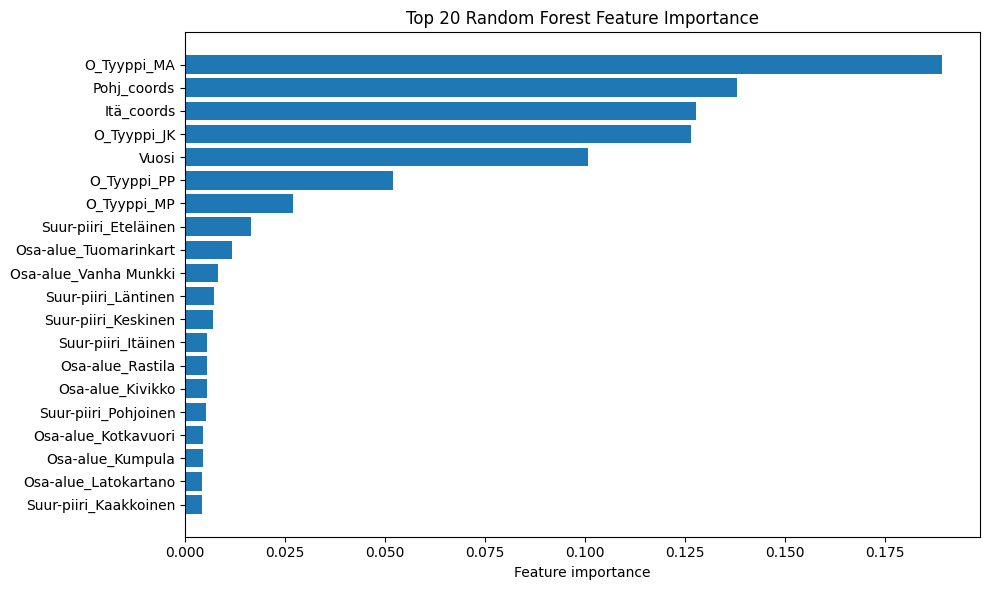

In [385]:
importances = best_rf.feature_importances_
features = rf_X_train.columns

feat_df = pd.DataFrame({"Feature": features, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Top 20 Random Forest Feature Importance")
plt.tight_layout()
plt.show()

### 4.12 Tree plot

Tarkastellaan Random Forest -mallin yksittäisten päätöspuiden rakennetta, jotta nähdään miten malli tekee luokittelupäätöksiä eri muuttujien perusteella. Alla visualisoidaan kolme puuta metsästä, ja kuvausta rajataan syvyyteen max_depth=3, jotta rakenne pysyy luettavana. Kuvaajien avulla voidaan tunnistaa, mitkä muuttujat ja jakoehdot korostuvat päätöksenteossa mallin alkuvaiheissa.

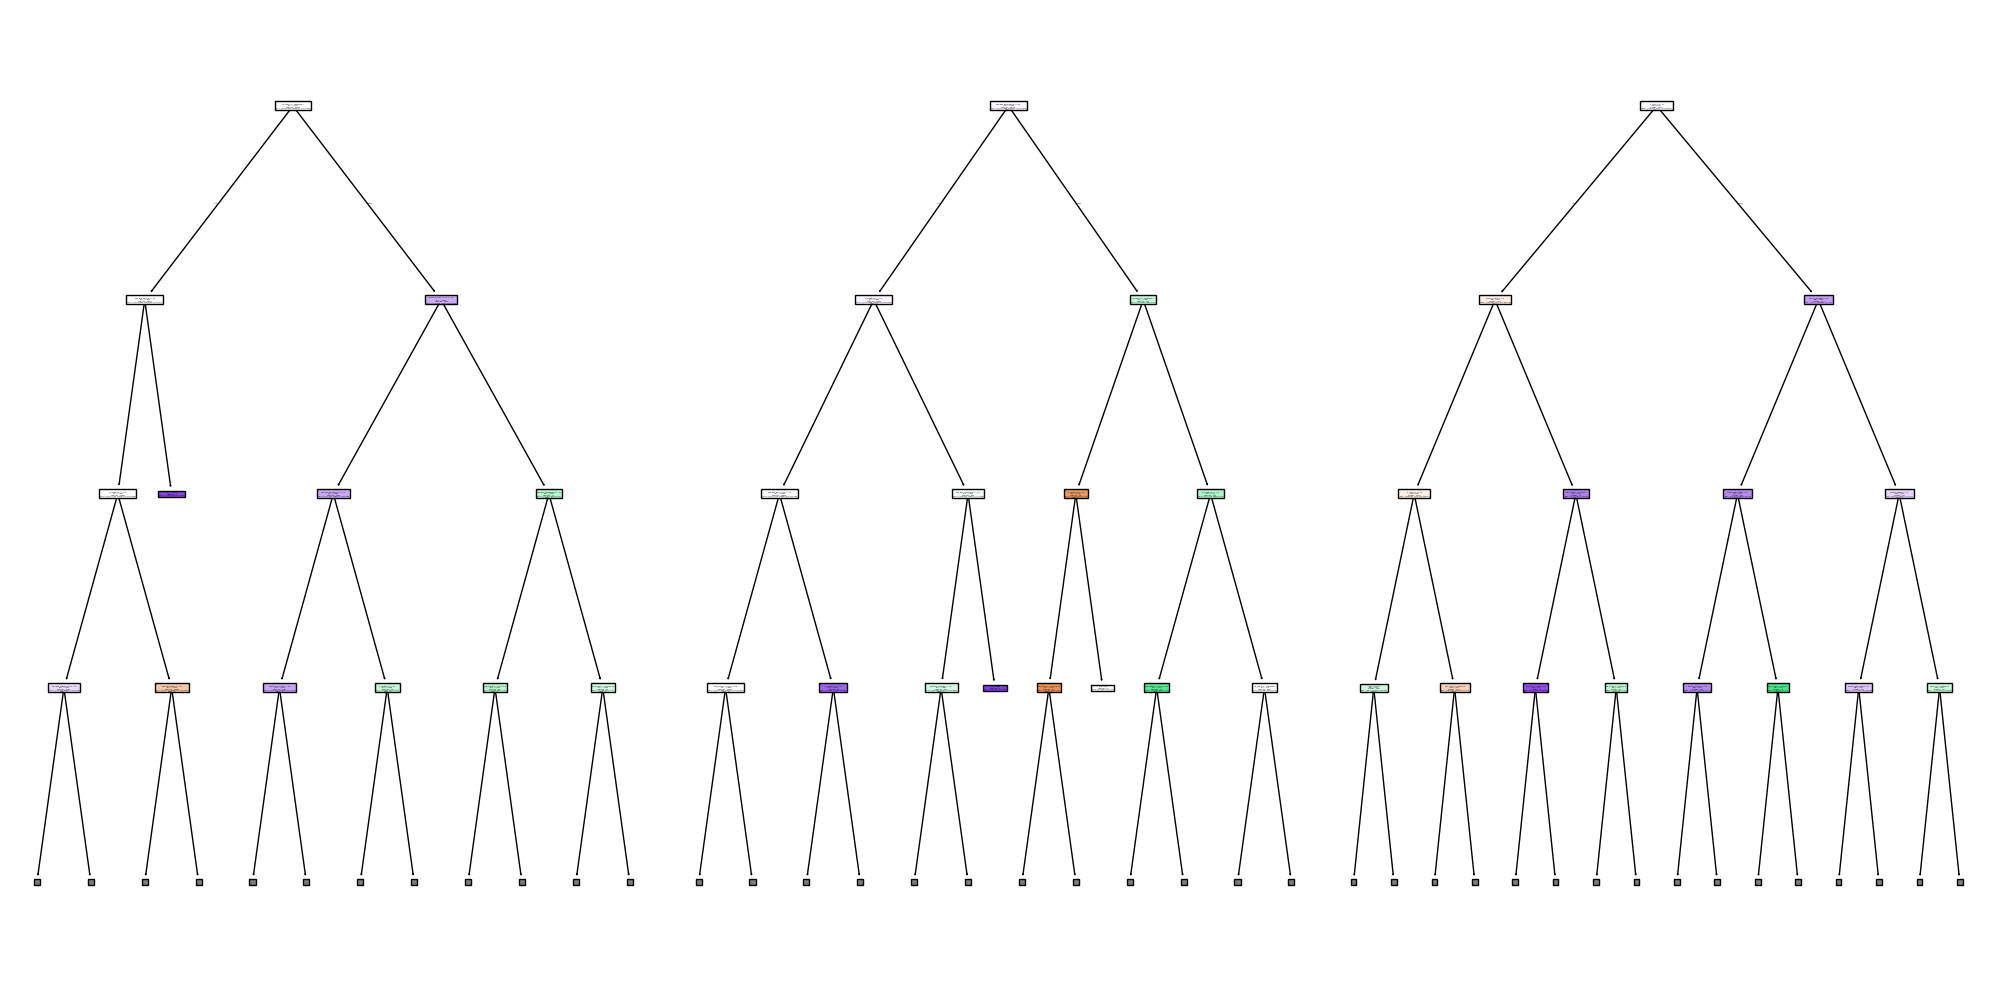

In [386]:
plt.figure(figsize=(20, 10))
for feat in range(3):
    plt.subplot(1, 3, feat+1)
    plot_tree(
        best_rf.estimators_[feat],
        filled=True,
        feature_names=rf_X_train.columns,
        class_names=['1', '2', '3'],
        max_depth=3
    )
plt.tight_layout()
plt.show()

### 4.2 Linear Regression

Luodaan lineaarisen regression malli ja sovitetaan se opetusjoukkoon

In [387]:
linear_model = LinearRegression()
linear_model.fit(X_tr_scaled, y_tr)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Tulostetaan mallin vakiotermi ja piirteiden kertoimet

In [388]:
print("Linear-regressiomallin parametrit:")
print(f"Vakiotermi (intercept): {linear_model.intercept_:.3f}")
for name, coef in zip(feature_cols, linear_model.coef_):
    print(f"  {name}: {coef:.3f}")

Linear-regressiomallin parametrit:
Vakiotermi (intercept): 21.240
  onnettomuudet_lag1: 25.365
  vakavuus_mean_lag1: 0.155
  pohj: -0.142
  ita: -0.073
  tyyppi_JK_osuus: 0.025
  tyyppi_MA_osuus: 0.140
  tyyppi_MP_osuus: 0.011
  tyyppi_PP_osuus: -0.228


Vakiotermi (intercept = 20.412) on ennuste, kun kaikki piirteet ovat 0 (lähtöpiste). Suurempi `coef` sen voimakkaampi vaikutus ennusteeseen. Positiivinen arvo lisää ennustetta ja kun taas negatiivinen vähentää.

 - Lag-piirteet (edellisen vuoden arvot) `onnettomuudet_lag1 = 25.110` on suurin vaikutus, edellisen vuoden onnettomuudet selittävät vahvasti seuraavan vuoden määrää. `vakavuus_mean_lag1 = 0.153` taas pieni positiivinen vaikutus.
- Koordinaateilla `pohj = -0.124`, `ita = -0.089` sijainneilla pieni negatiivinen vaikutus.
- Onnettomuustyyppien osuudet: `tyyppi_PP_osuus = -0.238`, `tyyppi_MA_osuus = 0.142` Muiden tyyppien osuudet vähäinen vaikutu

### 4.3 Logistic Regression

Luodaan logistisen regression malli ja sovitetaan sille __opetusjoukot__.

Mallille asetettiin `max_iter=700`, jotta mallin `solverit` ehtii yhtyä varmasti.
- Mallilla meni noin 500 iteraatiota yhtymiseen, joten arvoksi asetettiin `700` varmuuden vuoksi.

In [389]:
model = LogisticRegression(max_iter=700)
model.fit(log_X_train, log_y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Mallin päätarkoituksena on laskea riskisuhteita eli:
- "Kuinka moninkertainen onnettomuuden riskisuhde on verrattuna vertailuluokkaan."

Lasketaan selittävien muuttujien riskisuhteet:

| kerroinsuhde | tulkinta         |
| ----------   | ---------------- |
| 1            | ei vaikutusta    |
| >1           | kasvattaa riskiä |
| <1           | pienentää riskiä |


In [390]:
odds_ratios = np.exp(model.coef_[0])
importance = dict(zip(log_X_train.columns, odds_ratios))

print(f"Selittävän muuttujan merkitys:\n")
for feat, odds_ratio in importance.items():
    print(f"{feat}: {odds_ratio:.2f}")

Selittävän muuttujan merkitys:

Vuosi: 1.00
Suur-piiri_Itäinen: 2.23
Suur-piiri_Kaakkoinen: 1.85
Suur-piiri_Keskinen: 1.81
Suur-piiri_Koillinen: 2.05
Suur-piiri_Läntinen: 2.06
Suur-piiri_Pohjoinen: 2.25
Suur-piiri_Östersundom: 4.08
O_Tyyppi_JK: 30.65
O_Tyyppi_MP: 8.84
O_Tyyppi_PP: 14.65


#### Tulkinta

Logistisen regression riskisuhteita `(odds-suhteita)` tulkitaan suhteessa vertailuluokkiin.

Datan valmistelussa `pd.get_dummies(X_log, drop_first=True)`-metodi otti vertailuluokiksi:
- `Suur-piiri_Eteläinen`
- `O_Tyyppi_MA` eli Onnettomuustyypin MoottoriAjoneuvo

Tämä tarkoittaa, että muiden luokkien riskisuhteet kertovat, kuinka paljon vakavan onnettomuuden riski muuttuu verrattuna näihin vertailuluokkiin.

Esimerkiksi jos `O_Tyyppi_PP` saa arvon `14.65`, tämä tarkoittaa, että polkupyöräonnettomuuden vakavan onnettomuuden riski on noin __14.65-kertainen verrattuna moottoriajoneuvo-onnettomuuteen__.

## 5.0 Evaluation

### 5.1 Random Forest Evaluation

Random Forest -malli saavutti testiaineistolla noin 83 % tarkkuuden vakavuusluokan ennustamisessa. Malli toimii käytännössä parhaiten luokassa 1 (omaisuusvahinko), joka on aineistossa ylivoimaisesti yleisin. Luokkien 2 ja 3 ennustaminen on vaikeampaa luokkien epätasapainon vuoksi erityisesti kuolemaan johtaneita onnettomuuksia (luokka 3) on aineistossa vain 38 tapausta, mikä rajoittaa mallin oppimista niistä.

Käytännön sovellettavuuden kannalta mallilla voidaan tunnistaa riskiryhmiä ja -alueita: syöttämällä mallille sijainti-, onnettomuustyyppi- ja kaupunginosamuuttujat saadaan todennäköisyysarvio onnettomuuden vakavuusluokalle. Tätä voitaisiin hyödyntää esimerkiksi kaupunkisuunnittelussa tai liikenneturvallisuusanalyysissa kohdentamaan toimenpiteitä korkean riskin alueille.

Mallin rajoituksena on, että se on koulutettu vuosien 2000–2019 datalla, joten aineistossa ei näy esimerkiksi koronapandemian vaikutuksia liikennemääriin. Malli ei myöskään ota huomioon tiestön kuntoa, nopeusrajoituksia tai muita infrastruktuuritekijöitä, jotka voisivat parantaa ennustetarkkuutta erityisesti vakavampien onnettomuuksien osalta.

Arvioidaan Random Forest -mallin suorituskykyä testiaineistolla. Ensin muodostetaan ennusteet `(y_pred)` ja lasketaan mallin kokonais­tarkkuus (`accuracy`.Tämän jälkeen tarkastellaan sekaannusmatriisia (`confusion matrix`), joka näyttää luokkakohtaisesti, miten hyvin malli erottaa vakavuusluokat toisistaan.Lopuksi tulostetaan classification report, josta nähdään tarkemmin precision-, recall- ja F1-arvot jokaiselle luokalle.

Test accuracy: 0.832


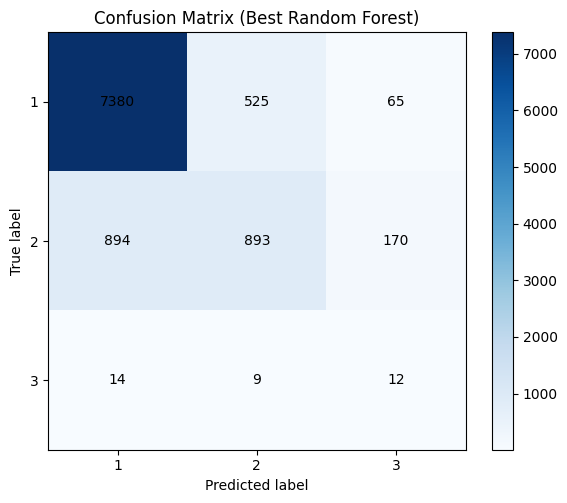

[[7380  525   65]
 [ 894  893  170]
 [  14    9   12]] 

              precision    recall  f1-score   support

           1       0.89      0.93      0.91      7970
           2       0.63      0.46      0.53      1957
           3       0.05      0.34      0.09        35

    accuracy                           0.83      9962
   macro avg       0.52      0.58      0.51      9962
weighted avg       0.84      0.83      0.83      9962



In [391]:
# Ennuste testidatasta
y_pred = best_rf.predict(rf_X_test)

test_accuracy = accuracy_score(rf_y_test, y_pred)

print(f"Test accuracy: {test_accuracy:.3f}")

# Confusion matrix
rf_cm = confusion_matrix(rf_y_test, y_pred)
labels = np.unique(np.concatenate([rf_y_test.values, y_pred]))

plt.figure(figsize=(6, 5))
plt.imshow(rf_cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix (Best Random Forest)")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")

for feat in range(rf_cm.shape[0]):
    for j in range(rf_cm.shape[1]):
        plt.text(j, feat, rf_cm[feat, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

print(rf_cm, "\n")
# Classification report
print(classification_report(rf_y_test, y_pred))

Tulosten perusteella malli saavuttaa testidatalla noin 83 % tarkkuuden. Malli toimii erittäin hyvin vakavuusluokassa 1 (omaisuusvahinko), luokka 2 (loukkaantuminen) ennustuu kohtalaisesti ja luokka 3 (kuolema) selvästi heikommin. Heikompi suoritus luokassa 3 johtuu todennäköisesti luokan pienestä havaintomäärästä (vain 38 tapausta), mikä tekee sen oppimisesta vaikeampaa.

### 5.2 Linear regression

Datasetin visualisointi osoitti, että vuosittaiset onnettomuusmäärät ovat melko "kohinaisia". Liikenneonnettomuuksiin vaikuttavat monet ulkoiset tekijät, joita datasetissä ei ole mukana, kuten liikennesääntöjen muutokset, uudet turvallisemmat tiet ja muut erikoistapaukset. Mallilla ennustaminen vuodelle 2019 R²-arvolla 0.8190 onnistui hyvin, mutta tulevien vuosien ennustaminen ei ole yhtä tarkkaa, koska ulkoiset tekijät muuttuvat. Esimerkiksi koronapandemian alkaessa 2020 liikenneonnettomuudet vähenivät merkittävästi, mikä ei olisi mallin ennustettavissa. Mallia voidaan kuitenkin käyttää analysoimaan hypotettisia skenaarioita, kuten arvioida onnettomuusmääriä ilman poikkeustekijöitä

Ennustetaan onnettomuudet opetus- ja testijoukoille

In [392]:
train_preds = linear_model.predict(X_tr_scaled)
test_preds  = linear_model.predict(X_te_scaled)

Piirretään residuaalit (todelliset − ennustetut) vs. ennustetut arvot. Residuaalit näyttävät, kuinka paljon malli yli- tai aliarvioi ennusteet

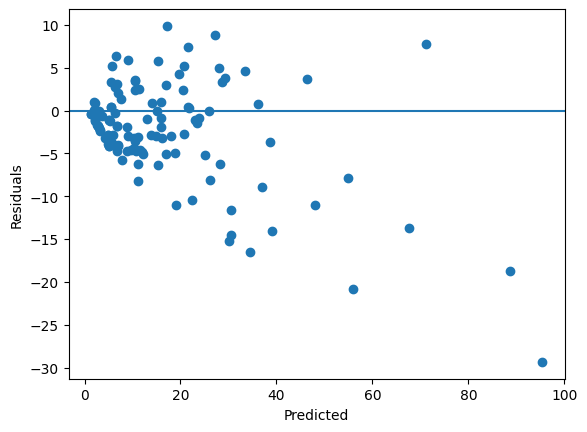

In [393]:
residuals = y_te - test_preds

plt.scatter(test_preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

Kuvassa näkyy, että pisteet ovat pääosin lähellä nollaa. Mitä suuremmiksi residuaalit kasvavat, sitä enemmän malli ennustaa liian suuria arvoja. Negatiiviset residuaalit tarkoittavat, että malli yliarvioi ennusteet, ja positiiviset residuaalit, että malli aliarvioi niitä. Kuva osoittaa, että malli hieman yliarvioi korkeita ennusteita, ja meidän tapauksessamme malli ennustaa vuoden 2019 onnettomuudet hieman yli, mutta yleinen trendi on oikein.

Piirretään scatter-plot kuvaaja todellisista ja ennustetuista onnettomuuksista

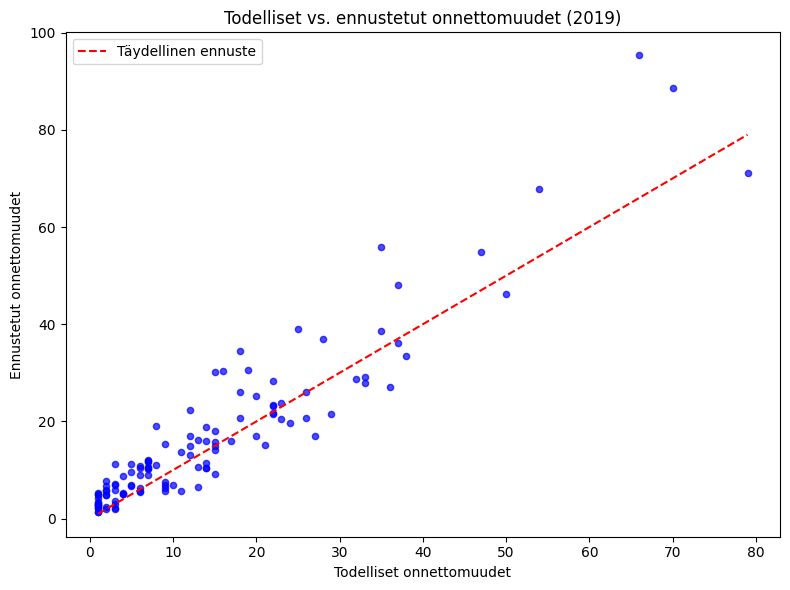


Total predicted accidents (2019): 1986
Total actual accidents (2019): 1705


In [394]:
plt.figure(figsize=(8, 6))
plt.scatter(y_te, test_preds, s=20, alpha=0.7, color='blue')
plt.plot(
    [y_te.min(), y_te.max()],
    [y_te.min(), y_te.max()],
    color='red', linestyle='--', label='Täydellinen ennuste'
)
plt.xlabel("Todelliset onnettomuudet")
plt.ylabel("Ennustetut onnettomuudet")
plt.title("Todelliset vs. ennustetut onnettomuudet (2019)")
plt.legend()
plt.tight_layout()
plt.show()

pred_2019_df = test_data[['Osa-alue']].copy()
pred_2019_df['Vuosi'] = 2019
pred_2019_df['predicted_accidents'] = test_preds
pred_2019_df['actual_accidents'] = y_te.values

total_pred_2019 = pred_2019_df['predicted_accidents'].sum()
total_actual_2019 = pred_2019_df['actual_accidents'].sum()

print(f"\nTotal predicted accidents (2019): {total_pred_2019:.0f}")
print(f"Total actual accidents (2019): {total_actual_2019:.0f}")

Jokainen piste kuvaa yhtä aluetta vuonna 2019.

- Pisteen x-koordinaatti kertoo todellisten onnettomuuksien määrän ja y-koordinaatti ennustetun määrän.
-  katkoviiva näyttää täydellisen ennusteen; pisteen ollessa viivalla ennuste vastaa todellisuutta.
- Piste viivan yläpuolella tarkoittaa, että malli yliarvioi ennusteen, kun taas piste viivan alapuolella tarkoittaa, että malli aliarvioi.
- Näin voidaan tarkastella kunkin alueen ennusteen tarkkuutta ja koko mallin yleistä trendiä.

### 5.21 Tehokkuus

Lasketaan regressiomallin suorituskyky opetus- ja testijoukossa käyttäen seuraavia mittareita:
- `R²` selitysaste, kertoo kuinka hyvin malli selittää havaittua vaihtelua
- `MAE` (Mean Absolute Error): keskimääräinen absoluuttinen virhe
- `RMSE` (Root Mean Squared Error): keskimääräinen neliöjuurivirhe

In [395]:
r2_train   = r2_score(y_tr, train_preds)
mae_train  = mean_absolute_error(y_tr, train_preds)
rmse_train = np.sqrt(mean_squared_error(y_tr, train_preds))

r2_test    = r2_score(y_te, test_preds)
mae_test   = mean_absolute_error(y_te, test_preds)
rmse_test  = np.sqrt(mean_squared_error(y_te, test_preds))

print("OPETUSJOUKKO")
print(f"  R²: {r2_train:.4f} | MAE: {mae_train:.4f} | RMSE: {rmse_train:.4f}")

print("\nTESTIJOUKKO (2019)")
print(f"  R²: {r2_test:.4f} | MAE: {mae_test:.4f} | RMSE: {rmse_test:.4f}")

print("\nEROTUS (opetus − testi)")
print(f"  R²: {r2_train - r2_test:.4f} | MAE: {mae_train - mae_test:.4f} | RMSE: {rmse_train - rmse_test:.4f}")


OPETUSJOUKKO
  R²: 0.9107 | MAE: 5.1922 | RMSE: 7.9640

TESTIJOUKKO (2019)
  R²: 0.8129 | MAE: 4.5125 | RMSE: 6.4530

EROTUS (opetus − testi)
  R²: 0.0979 | MAE: 0.6797 | RMSE: 1.5111


Malli selittää hyvin vaihtelua sekä opetus- että testijoukossa (korkeat R²-arvot). Pienet erot opetus- ja testijoukon mittareissa osoittavat, että malli yleistyy hyvin uusiin datoihin eikä ylitäoppine. RMSE ja MAE ovat kohtuullisen pieniä suhteessa onnettomuuksien lukumääriin, mikä tukee mallin toimivuutta opetusesimerkissä.

### 5.22 Ennuste vuosi 2020 onnettomuudet

Lasketaan vuoden 2019 piirteet lag-arvoiksi vuoden 2020 ennustetta varten. Lag-piirteet sisältävät edellisen vuoden (2019) onnettomuudet ja vakavuuden keskiarvon. Onnettomuustyyppien osuudet kopioidaan suoraan vuoden 2019 datasta. Piirteet skaalataan samalla StandardScalerilla kuin opetusdata ja syötetään lineaariseen regressiomalliin ennustetta varten. Tulokset sisältävät kunkin alueen ennustetut onnettomuudet sekä kokonaisennusteen vuodelle 2020.

In [396]:
# Lasketaan 2019 piirteet lag-arvoiksi 2020 ennustetta varten
data_2019 = yearly_accidents[yearly_accidents['Vuosi'] == 2019].copy()

predict_2020 = data_2019[['Osa-alue', 'pohj', 'ita']].copy()

# Viime vuoden (2019) arvot lag-piirteiksi
predict_2020['onnettomuudet_lag1'] = data_2019['onnettomuudet'].values
predict_2020['vakavuus_mean_lag1'] = data_2019['vakavuus_mean'].values

# Onnettomuustyyppien osuudet 2019 datasta
for col in [c for c in data_2019.columns if c.startswith('tyyppi_')]:
    predict_2020[col] = data_2019[col].values

# Skaalaus ja ennuste
X_2020 = predict_2020[feature_cols]
X_2020_scaled = pd.DataFrame(scaler.transform(X_2020), columns=feature_cols)
preds_2020 = linear_model.predict(X_2020_scaled)

predict_2020['ennustettu_2020'] = preds_2020
print(predict_2020[['Osa-alue', 'ennustettu_2020']])
print(f"\nYhteensä ennustettu 2020: {preds_2020.sum():.0f}")

          Osa-alue  ennustettu_2020
19       Ala-Malmi        33.134640
39       Alppikylä         1.877858
59         Alppila        12.645589
99    Aurinkolahti         2.980209
119           Eira         4.568908
...            ...              ...
2719   Viikinranta        14.419750
2739   Vilhonvuori        14.836814
2759      Yliskylä         7.690859
2779     Ylä-Malmi         3.920884
2799   Östersundom         7.018422

[117 rows x 2 columns]

Yhteensä ennustettu 2020: 1709


Ennuste osoittaa mallin pystyvän arvioimaan aluekohtaisia trendejä myös tulevalle vuodelle, vaikka absoluuttiset arvot voivat hieman poiketa todellisuudesta.

### 5.3 Logistic Regression Evaluation


Tarkastellaan logistisen regression sekaannusmatriisia `confusion_matrix` ja luokitteluraporttia `classification_report`.

Nämä näyttävät, kuinka hyvin malli erottaa omaisuusvahingot ja vakavat onnettomuudet toisistaan testiaineistossa.

Logistisen Regressiomallin Accuracy: 0.8587


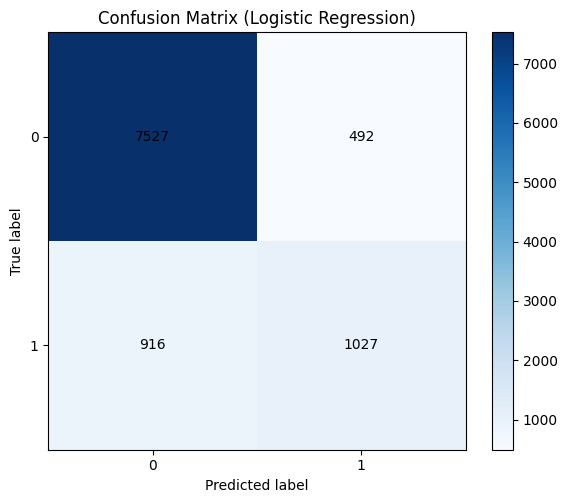

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      8019
           1       0.68      0.53      0.59      1943

    accuracy                           0.86      9962
   macro avg       0.78      0.73      0.75      9962
weighted avg       0.85      0.86      0.85      9962



In [397]:
log_y_pred = model.predict(log_X_test)
log_accuracy = accuracy_score(log_y_test, log_y_pred)
print(f"Logistisen Regressiomallin Accuracy: {log_accuracy:.4f}")

log_cm = confusion_matrix(log_y_test, log_y_pred)
labels = np.unique(np.concatenate([log_y_test.values, log_y_pred]))

plt.figure(figsize=(6, 5))
plt.imshow(log_cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix (Logistic Regression)")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(log_cm.shape[0]):
    for j in range(log_cm.shape[1]):
        plt.text(j, i, log_cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

print(classification_report(log_y_test, log_y_pred))

#### Logistisen Regression Tulokset

Logistisen regression päätavoite ei ollut mallin suorituskyvyn arviointi, vaan riskisuhteiden tulkinta. Tästä huolimatta käydään silti läpi, miten malli onnistui ennustamaan omaisuusvahinkojen ja vakavien onnettomuuksien välillä.

Logistisen regression tulosten perusteella:
- Malli ennustaa oikeita omaisuusvahingon ja vakavan onnettomuuden luokkia `86%` tarkkuudella.
- Vakavien onnettomuuksien ennustaminen oli mallille vaikeaa:
    - Malli ennusti oikein 1027 vakavaa onnettomuutta, mutta missaa 916, joka vastaa `53%` recallia.
    - Malli ennusti yhteensä 1519 vakavaa onnettomuutta, mutta antoi 492 väärää hälytystä, joka vastaa `68%` precisionia.

## 6.0 Deployment